In [1]:
import os
import copy

from itertools import chain, combinations

from sklearn import linear_model
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score

import pandas as pd
import numpy as np

import torch
import tensorkrowch as tk
from tensorkrowch.decompositions import tt_rss
import matplotlib.pyplot as plt

from interpretability import *

## Train LR model

In [2]:
cwd = os.path.join(os.getcwd(), '..')

model_name = 'llr6'
n_classes = 2

In [3]:
# Load data
# ---------
featuresNA = ['TMB', 'Albumin', 'NLR', 'Age', 'Systemic_therapy_history',
              'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
              'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
              'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
              'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']
phenoNA = 'Response'

numeric_featuresNA = ['TMB', 'Albumin', 'NLR', 'Age']

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']

# scaler_type = 'MinMax'
scaler_type = 'Standard'

dataset = 'Chowell_train'
data_train, scalers_train = load_data(cwd,
                                      featuresNA,
                                      phenoNA,
                                      numeric_featuresNA,
                                      dataset,
                                      scaler_type)

dataset = 'Chowell_test'
data_test, scalers_test = load_data(cwd,
                                    featuresNA,
                                    phenoNA,
                                    numeric_featuresNA,
                                    dataset,
                                    scaler_type)

In [4]:
# Train model
# -----------
x_train = data_train[featuresNA].values
y_train = data_train[phenoNA].values

x_test = data_test[featuresNA].values
y_test = data_test[phenoNA].values

print('\n* TRAINING MODEL:')
loris = train_model(model_name, x_train, y_train, x_test, y_test)


* TRAINING MODEL:
Model accuracy: Train: 0.69, Test: 0.73
Model balanced accuracy: Train: 0.67, Test: 0.69



## Tensorize

In [5]:
# Tensorize model
# ---------------
xt_train = torch.from_numpy(x_train).float()
yt_train = torch.from_numpy(y_train)

xt_test = torch.from_numpy(x_test).float()
yt_test = torch.from_numpy(y_test)

# sketch_size could be chosen smaller, e.g., sketch_size = 50, and the
# tensorization will be much faster returning a tt_model with the same accuracy,
# but sometimes this could lead to having negative values for inputs with low
# probability. Choosing a bigger sketch_size usually avoids these errors.
sketch_size    = 200
phys_dim       = 2
domain         = torch.linspace(0, 1, phys_dim)
bond_dim       = 2
cum_percentage = 1 - 1e-5
batch_size     = 500
device         = torch.device('cpu')
dtype          = torch.float
verbose        = False

print('* TENSORIZING MODEL:')
mps = tensorize(model=loris,
                x_train=xt_train,
                y_train=yt_train,
                x_test=xt_test,
                y_test=yt_test,
                sketch_size=sketch_size,
                phys_dim=phys_dim,
                domain=domain,
                bond_dim=bond_dim,
                cum_percentage=cum_percentage,
                batch_size=batch_size,
                device=device,
                dtype=dtype,
                verbose=verbose)

* TENSORIZING MODEL:
Info: {'total_time': 4.2232890129089355, 'val_eps': tensor(0.0384)}
MSE: Train: 0.0005, Test: 4.66e-04
tensor([[0.6445, 0.3576],
        [0.4126, 0.5953],
        [0.5811, 0.4232],
        [0.4447, 0.5624],
        [0.5472, 0.4623],
        [0.7237, 0.2739],
        [0.6592, 0.3429],
        [0.3005, 0.7038],
        [0.5804, 0.4247],
        [0.7296, 0.2690]])
tensor([[0.6507, 0.3493],
        [0.4098, 0.5902],
        [0.5852, 0.4148],
        [0.4470, 0.5530],
        [0.5521, 0.4479],
        [0.7213, 0.2787],
        [0.6621, 0.3379],
        [0.2906, 0.7094],
        [0.5854, 0.4146],
        [0.7265, 0.2735]])
Model accuracy: Train: 0.70, Test: 0.73
Model balanced accuracy: Train: 0.68, Test: 0.69



In [6]:
# Renormalize model
# -----------------

# We renormalize the tensor network so that it represents a normalized
# distribution of all the features, instead of only giving normalized
# conditional distributions for the output feature ("Response")

# Contiuous variables have to be integrated. "discr_steps" indicates the number
# of dicretization steps used to discretize the continuous variable and perform
# numerical integration
discr_steps = int(1e5)

print('* RENORMALIZING TN MODEL:')
mps = renormalize(mps=mps,
                  phys_dim=phys_dim,
                  discr_steps=discr_steps,
                  n_classes=n_classes,
                  num_features=numeric_featuresNA,
                  x_train=xt_train,
                  x_test=xt_test,
                  y_test=yt_test)

* RENORMALIZING TN MODEL:
Model accuracy: Test: 0.73
Model balanced accuracy: Test: 0.69



In [7]:
def lr_model(data):
    result = torch.from_numpy(loris.predict_proba(data)).float()
    return result

def embedding(data):
    return tk.embeddings.poly(data, degree=phys_dim - 1).float()

def tt_model(data):
    return mps(embedding(data))

In [8]:
lr_model(xt_test)

tensor([[0.2690, 0.7310],
        [0.4553, 0.5447],
        [0.5092, 0.4908],
        ...,
        [0.5941, 0.4059],
        [0.7672, 0.2328],
        [0.5442, 0.4558]])

In [9]:
tt_model(xt_test)

tensor([[2.1114e-06, 5.4015e-06],
        [3.5151e-06, 4.1002e-06],
        [3.8926e-06, 3.7516e-06],
        ...,
        [4.4936e-06, 3.1664e-06],
        [5.8971e-06, 1.6785e-06],
        [4.0496e-06, 3.5510e-06]], grad_fn=<ViewBackward0>)

In [10]:
tt_model(xt_test) / tt_model(xt_test).sum(dim=1, keepdim=True)

tensor([[0.2810, 0.7190],
        [0.4616, 0.5384],
        [0.5092, 0.4908],
        ...,
        [0.5866, 0.4134],
        [0.7784, 0.2216],
        [0.5328, 0.4672]], grad_fn=<DivBackward0>)

## Study distributions

### Examples

In [11]:
# Get conditional/marginal distribution
# -------------------------------------

# We need to specify the condition and marginal variables. The rest will be
# marginalized out. The "Response" feature can be included as condition or
# marginal

# Select features on which we condition
cond_features = ['TMB', 'Albumin']

# Create tensor with values (already scaled to [0, 1])
# for conditioned features
cond_data = [0.2, 0.9]  # Just an example

# Select features which we marginalize
marg_features = ['Systemic_therapy_history', 'Response']

# In this example, we will get the distribution 
# P('Systemic_therapy_history', 'Response' | 'TMB', 'Albumin'),
# marginalizing out the rest of the features

# The distribution will be given as a tensor with shape:
# (dim_marg_1, ..., dim_marg_n), with "dim_marg_{i}" being the dimensions of
# each marginal feature. These marginal features could be returned in a
# different order as the one specified in "marg_features". The order will
# be returned in the list "marg_feat_order"

# For continuous features, the dimension of the marginal features will be the
# specified "discr_steps"

discr_steps = int(1e5)

distr, marg_feat_order = get_distribution(
    mps=mps,
    cond_features=cond_features,
    cond_data=cond_data,
    marg_features=marg_features,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=discr_steps
)

print(marg_feat_order, distr.shape)
print(distr)
print(distr.sum())
print(marg_feat_order[1], distr.sum(dim=0))
print(marg_feat_order[0], distr.sum(dim=1))
print()

['Systemic_therapy_history', 'Response'] torch.Size([2, 2])
tensor([[0.1934, 0.3067],
        [0.2870, 0.2130]])
tensor(1.0000)
Response tensor([0.4804, 0.5196])
Systemic_therapy_history tensor([0.5000, 0.5000])



In [12]:
# Example 2
cond_features = ['Response']
cond_data = [1.]

marg_features = ['TMB']

discr_steps = int(1e1)  # int(1e5)

distr, marg_feat_order = get_distribution(
    mps=mps,
    cond_features=cond_features,
    cond_data=cond_data,
    marg_features=marg_features,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=discr_steps
)

print(marg_feat_order, distr.shape)
print(distr)
print(distr.sum())
print()

['TMB'] torch.Size([10])
tensor([0.0584, 0.0676, 0.0769, 0.0861, 0.0954, 0.1046, 0.1139, 0.1231, 0.1324,
        0.1416])
tensor(1.)



In [13]:
# Example 3
cond_features = ['Systemic_therapy_history']
cond_data = [0.]

marg_features = ['Response']

discr_steps = int(1e5)

distr, marg_feat_order = get_distribution(
    mps=mps,
    cond_features=cond_features,
    cond_data=cond_data,
    marg_features=marg_features,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=discr_steps
)

print(marg_feat_order, distr.shape)
print(distr)
print(distr.sum())
print()

['Response'] torch.Size([2])
tensor([0.4005, 0.5995])
tensor(1.)



In [14]:
# Example 4
cond_features = []
cond_data = []

marg_features = ['Response', 'Albumin']

discr_steps = int(1e1)  # int(1e5)

distr, marg_feat_order = get_distribution(
    mps=mps,
    cond_features=cond_features,
    cond_data=cond_data,
    marg_features=marg_features,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=discr_steps
)

print(marg_feat_order, distr.shape)
print(distr / distr.sum(dim=1, keepdim=True))
print()

['Albumin', 'Response'] torch.Size([10, 2])
tensor([[0.6835, 0.3165],
        [0.6417, 0.3583],
        [0.5998, 0.4002],
        [0.5578, 0.4422],
        [0.5158, 0.4842],
        [0.4737, 0.5263],
        [0.4315, 0.5685],
        [0.3892, 0.6108],
        [0.3469, 0.6531],
        [0.3045, 0.6955]])



### Feature Importance

In [15]:
# TMB: We know TMB above 27 indicates better response

low = marginal_prediction(
    mps=mps,
    cond_feature='TMB',
    cond_data=5,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

mid = marginal_prediction(
    mps=mps,
    cond_feature='TMB',
    cond_data=27,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

high = marginal_prediction(
    mps=mps,
    cond_feature='TMB',
    cond_data=50,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

print('TMB Example:')
print(f'TT Score: {low:.4f}, {mid:.4f}, {high:.4f}')
print()

TMB Example:
TT Score: 0.3396, 0.5217, 0.7089



In [16]:
# Age: We know Age has a small impact on response

low = marginal_prediction(
    mps=mps,
    cond_feature='Age',
    cond_data=30,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

mid = marginal_prediction(
    mps=mps,
    cond_feature='Age',
    cond_data=50,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

high = marginal_prediction(
    mps=mps,
    cond_feature='Age',
    cond_data=80,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

print('Age Example:')
print(f'TT Score: {low:.4f}, {mid:.4f}, {high:.4f}')
print()

Age Example:
TT Score: 0.4828, 0.5053, 0.5391



In [17]:
# PSTH: We know that history of treatment lowers effectiveness of treatment

low = marginal_prediction(
    mps=mps,
    cond_feature='Systemic_therapy_history',
    cond_data=0,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

high = marginal_prediction(
    mps=mps,
    cond_feature='Systemic_therapy_history',
    cond_data=1,
    in_features=featuresNA,
    out_feature=phenoNA,
    num_features=numeric_featuresNA,
    n_classes=n_classes,
    phys_dim=phys_dim,
    x_train=xt_train,
    discr_steps=int(1e5),
    scalers_dict=scalers_train
)

print('PSTH Example:')
print(f'TT Score: {low:.4f}, {high:.4f}')
print()

PSTH Example:
TT Score: 0.5995, 0.4111



### Individual Patient Predictions

In [18]:
# Patient 1 -> Cancer: Melanoma, PSTH: No, Age: 64, Albumin: 4.8
#              NLR: 4.7, PD-L1: –, TMB: 21

patient = [21, 4.8, 4.7, 64, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]

lr_result = patient_prediction(lr_model, patient, featuresNA, scalers_train)
tt_result = patient_prediction(tt_model, patient, featuresNA, scalers_train)

print('Patient 1:')
print(f'TT Score: {tt_result:.4f}, LORIS score: {lr_result:.4f}')
print()

Patient 1:
TT Score: 0.8054, LORIS score: 0.8056



In [19]:
# Patient 2 -> Cancer: NSCLC, PSTH: Yes, Age: 50, Albumin: 3.5,
#              NLR: 6.3, PD-L1: –, TMB: 8

patient = [8, 3.5, 6.3, 50, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]

lr_result = patient_prediction(lr_model, patient, featuresNA, scalers_train)
tt_result = patient_prediction(tt_model, patient, featuresNA, scalers_train)

print('Patient 2:')
print(f'TT Score: {tt_result:.4f}, LORIS score: {lr_result:.4f}')
print()

Patient 2:
TT Score: 0.3363, LORIS score: 0.3316



In [20]:
# Patient 3 -> Cancer: Breast, PSTH: No,, Age: 42, Albumin: 4.6,
#              NLR: 2.3, PD-L1: –, TMB: 5

patient = [5, 4.6, 2.3, 42, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

lr_result = patient_prediction(lr_model, patient, featuresNA, scalers_train)
tt_result = patient_prediction(tt_model, patient, featuresNA, scalers_train)

print('Patient 3:')
print(f'TT Score: {tt_result:.4f}, LORIS score: {lr_result:.4f}')
print()


Patient 3:
TT Score: 0.6663, LORIS score: 0.6714



### Feature Sensitivity

Conditioning on mean values

In [21]:
aux_features = ['TMB', 'Albumin', 'NLR', 'Age',
                'Systemic_therapy_history']  #, 'CancerType']

# Collect sensitivity scores
lr_scores = []
tt_scores = []
for feat in aux_features:
    lr_scores.append(feature_sensitivity_cond(feat, lr_model, xt_train,
                                              featuresNA, scalers_train))
    tt_scores.append(feature_sensitivity_cond(feat, tt_model, xt_train,
                                              featuresNA, scalers_train))

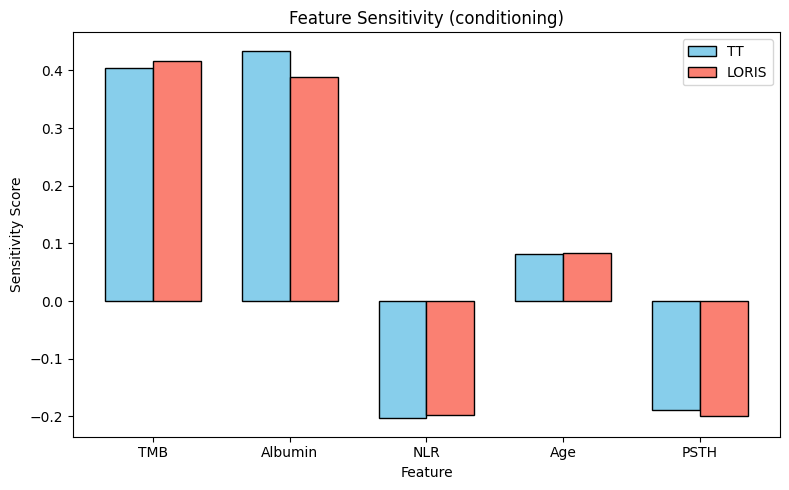

In [22]:
# Bar plot setup
x = torch.arange(len(aux_features))  # label locations
width = 0.35  # width of the bars

# Replace label just for plotting
plot_labels = ['PSTH' if feat == 'Systemic_therapy_history' else feat
               for feat in aux_features]

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, tt_scores, width, 
               label='TT', color='skyblue', edgecolor='black')
bars2 = ax.bar(x + width/2, lr_scores, width, 
               label='LORIS', color='salmon', edgecolor='black')

# Axes settings
ax.set_xlabel('Feature')
ax.set_ylabel('Sensitivity Score')
ax.set_title('Feature Sensitivity (conditioning)')
ax.set_xticks(x)
ax.set_xticklabels(plot_labels)
ax.legend()
plt.tight_layout()
plt.show()

Marginalizing variables

In [23]:
aux_features = ['TMB', 'Albumin', 'NLR', 'Age',
                'Systemic_therapy_history']  #, 'CancerType']

# Collect sensitivity scores
lr_scores = []
tt_scores = []
for feat in aux_features:
    lr_scores.append(feature_sensitivity_cond(feat, lr_model, xt_train,
                                              featuresNA, scalers_train))
    tt_scores.append(feature_sensitivity_marg(feature=feat,
                                              mps=mps,
                                              in_features=featuresNA,
                                              out_feature=phenoNA,
                                              num_features=numeric_featuresNA,
                                              n_classes=n_classes,
                                              phys_dim=phys_dim,
                                              x_train=xt_train,
                                              discr_steps=int(1e5),
                                              scalers_dict=scalers_train))

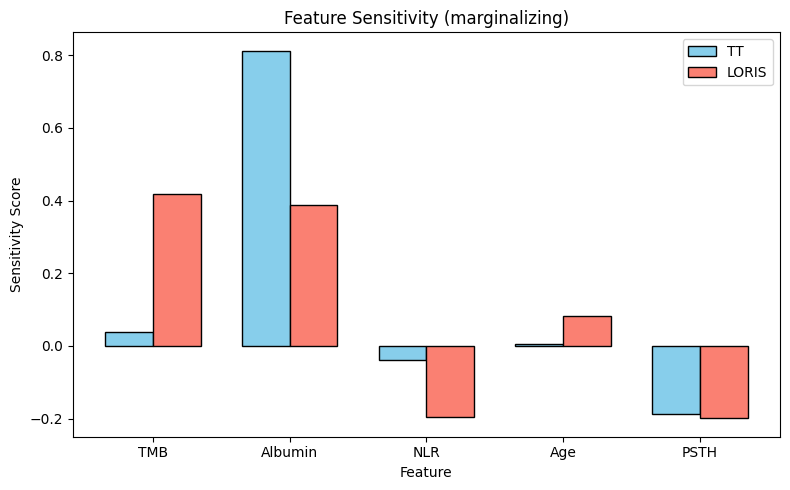

In [24]:
# Bar plot setup
x = torch.arange(len(aux_features))  # label locations
width = 0.35  # width of the bars

# Replace label just for plotting
plot_labels = ['PSTH' if feat == 'Systemic_therapy_history' else feat
               for feat in aux_features]

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, tt_scores, width, 
               label='TT', color='skyblue', edgecolor='black')
bars2 = ax.bar(x + width/2, lr_scores, width, 
               label='LORIS', color='salmon', edgecolor='black')

# Axes settings
ax.set_xlabel('Feature')
ax.set_ylabel('Sensitivity Score')
ax.set_title('Feature Sensitivity (marginalizing)')
ax.set_xticks(x)
ax.set_xticklabels(plot_labels)
ax.legend()
plt.tight_layout()
plt.show()

Recovering LR coefficiets from the TT

In [25]:
aux_features = ['TMB', 'Albumin', 'NLR', 'Age',
                'Systemic_therapy_history']  #, 'CancerType']

# Collect sensitivity scores
lr_scores = loris.coef_.tolist()[0][:5]
tt_scores = []
for feat in aux_features:
    tt_scores.append(feature_sensitivity_coeffs(feat, tt_model, xt_train,
                                                featuresNA, scalers_train))

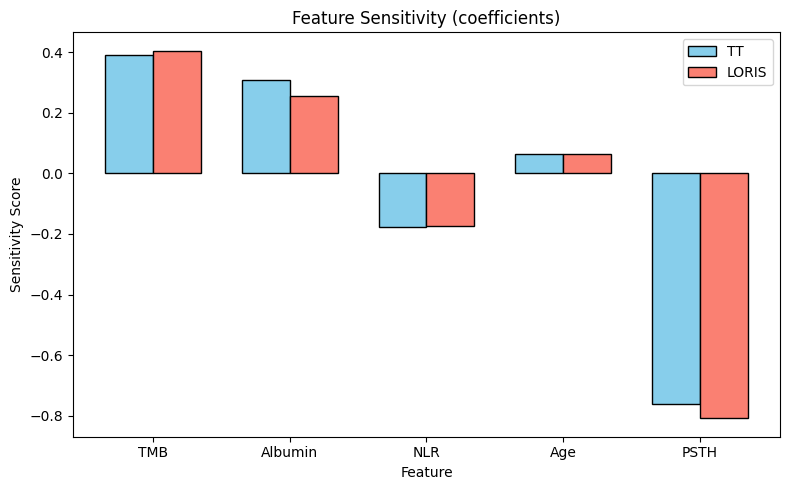

In [26]:
# Bar plot setup
x = torch.arange(len(aux_features))  # label locations
width = 0.35  # width of the bars

# Replace label just for plotting
plot_labels = ['PSTH' if feat == 'Systemic_therapy_history' else feat
               for feat in aux_features]

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, tt_scores, width, 
               label='TT', color='skyblue', edgecolor='black')
bars2 = ax.bar(x + width/2, lr_scores, width, 
               label='LORIS', color='salmon', edgecolor='black')

# Axes settings
ax.set_xlabel('Feature')
ax.set_ylabel('Sensitivity Score')
ax.set_title('Feature Sensitivity (coefficients)')
ax.set_xticks(x)
ax.set_xticklabels(plot_labels)
ax.legend()
plt.tight_layout()
plt.show()

## Monotonic plots

In [27]:
# Load data
# ---------
featuresNA = ['TMB', 'Albumin', 'NLR', 'Age', 'Systemic_therapy_history',
              'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
              'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
              'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
              'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']
phenoNA = 'Response'

numeric_featuresNA = ['TMB', 'Albumin', 'NLR', 'Age']

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']

# scaler_type = 'MinMax'
scaler_type = 'Standard'

dataset = 'Chowell_train' # 'MSK1', 'MSK2'
data_train, scalers_train = load_data(cwd,
                                      featuresNA,
                                      phenoNA,
                                      numeric_featuresNA,
                                      dataset,
                                      scaler_type)

x_train = data_train[featuresNA].values
y_train = data_train[phenoNA].values

xt_train = torch.from_numpy(x_train).float()
yt_train = torch.from_numpy(y_train)

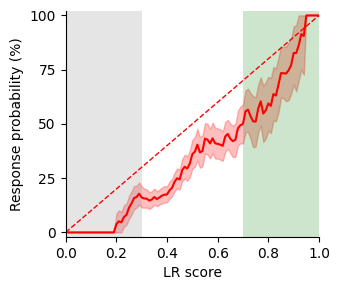

In [28]:
response_curve(lr_model, xt_train, yt_train, xlabel='LR score')

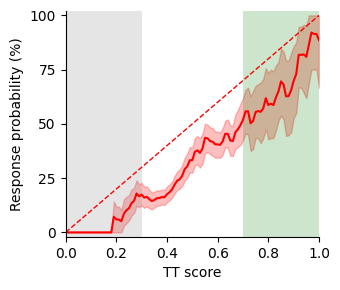

In [29]:
response_curve(tt_model, xt_train, yt_train, xlabel='TT score')